# Multinomial Logistic Regression in R

## Overview

Multinomial logistic regression extends binary logistic regression to outcomes with **three or more unordered categories**. It fits a separate set of log-odds coefficients for each category relative to a chosen reference category, so a model with k outcome levels produces k-1 sets of coefficients.

| Model | Use Case |
|---|---|
| Multinomial logistic regression | 3+ outcome categories with no natural order |
| Binary logistic regression | 2 outcome categories (see `logistic_regression.ipynb`) |
| Ordinal logistic regression | 3+ outcome categories with a meaningful order (see `ordinal_regression.ipynb`) |

> **Key output: relative risk ratios (RRR) / odds ratios per category**  
> Each coefficient compares one outcome category to the reference category.  
> A positive coefficient means the predictor increases the log-odds of that category vs. the reference.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | What environmental variables predict which foraging behavior a tern exhibits (diving, hovering, or transiting)? What predicts habitat type used (marsh, upland, or mudflat)? |
| **Healthcare** | What patient characteristics predict diagnosis category (condition A, B, or C)? What factors predict discharge disposition (home, rehab, or long-term care)? |
| **Finance** | What features predict credit rating category (AAA, AA, A, BBB)? What predicts customer segment (high-value, mid-tier, or at-risk)? |
| **Insurance** | What policyholder characteristics predict claim type (property, liability, or no claim)? What predicts policy tier chosen? |

---

## Assumptions Checklist

- [ ] **Unordered outcome:** Categories have no natural ranking — if they do, use ordinal regression instead
- [ ] **Independence of observations:** No repeated measures or clustering
- [ ] **Independence of irrelevant alternatives (IIA):** The odds ratio between any two categories is unaffected by the presence or absence of other categories — test with Hausman-McFadden test
- [ ] **Linearity of log-odds:** Each continuous predictor has a linear relationship with the log-odds for each category comparison
- [ ] **No perfect separation:** No predictor perfectly predicts membership in any category
- [ ] **Adequate sample size:** At least 10-20 observations per outcome category per predictor (events per variable rule applies per category)
- [ ] **No severe multicollinearity:** Check with VIF on component binary models

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)
library(ggplot2)
library(nnet)         # multinom() for multinomial logistic regression
library(broom)        # tidy model output
library(car)          # VIF
library(effects)      # marginal effects plots
library(ggeffects)    # ggplot2-compatible marginal effects

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'broom' was built under R version 4.4.3"
Warning message:
"package 'car' was built under R version 4.4.3"
L

## Data

We use the built-in `iris` dataset: species (setosa, versicolor, virginica) as the three-category unordered outcome, predicted by sepal and petal measurements. This is a classic multiclass classification problem — the same structure applies directly to habitat type, diagnosis category, or customer segment.


    setosa versicolor  virginica 
        50         50         50 


    setosa versicolor  virginica 
 0.3333333  0.3333333  0.3333333 

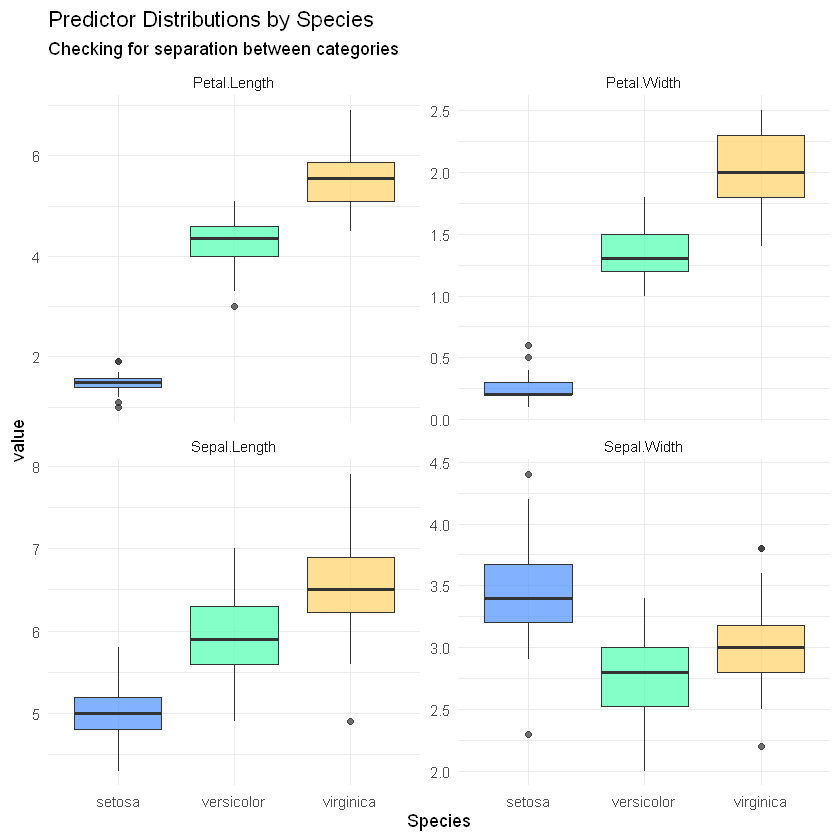

In [2]:
# ── Inspect outcome distribution ──────────────────────────────────────────────
table(iris$Species)
prop.table(table(iris$Species))
# Balanced classes here — real data often is not

# ── Set reference category ────────────────────────────────────────────────────
# All coefficients will be interpreted relative to this category
# Choose the most natural reference (e.g. control group, most common category)
iris$Species <- relevel(iris$Species, ref = "setosa")

# ── Exploratory: predictor distributions by species ───────────────────────────
iris %>%
  pivot_longer(cols = -Species, names_to = "measure", values_to = "value") %>%
  ggplot(aes(x = Species, y = value, fill = Species)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~measure, scales = "free_y") +
  scale_fill_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  labs(title = "Predictor Distributions by Species",
       subtitle = "Checking for separation between categories") +
  theme_minimal() +
  theme(legend.position = "none")

---

## Assumptions Testing

Observations per category:

    setosa versicolor  virginica 
        50         50         50 

Minimum recommended per category: 20


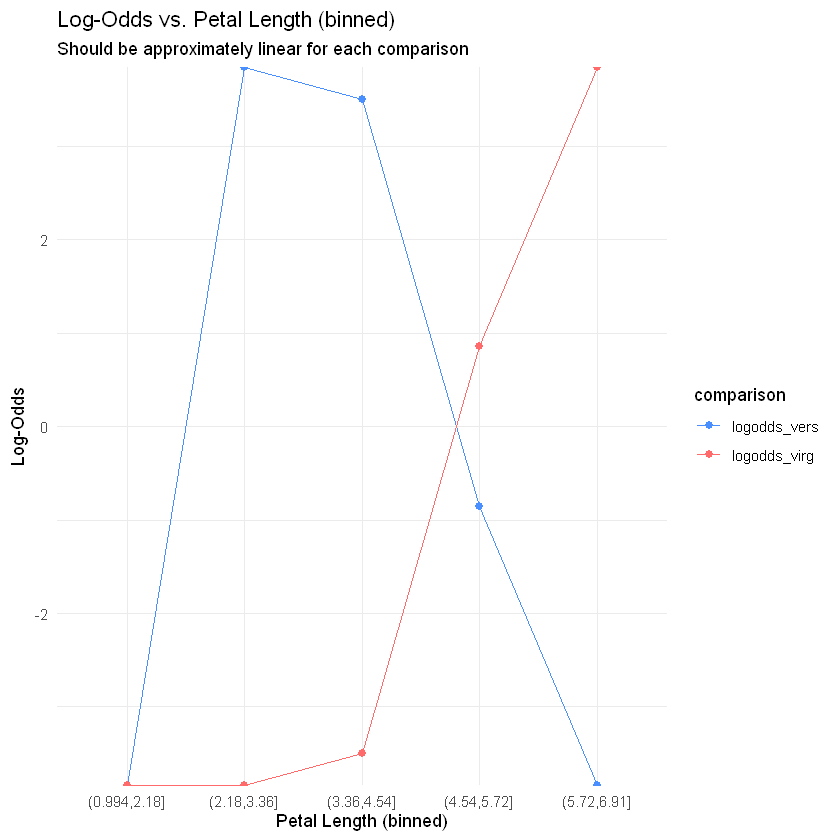

In [3]:
# ── Sample size per category ──────────────────────────────────────────────────
# Rough guideline: >= 10-20 observations per category per predictor
n_predictors <- 2  # wt and hp in our model
cat("Observations per category:\n")
print(table(iris$Species))
cat(sprintf("\nMinimum recommended per category: %d\n", n_predictors * 10))

# ── Linearity of log-odds: check visually per category ───────────────────────
# Create binary indicators for each category vs. reference
iris_check <- iris %>%
  mutate(
    versicolor_vs_setosa = as.integer(Species == "versicolor"),
    virginica_vs_setosa  = as.integer(Species == "virginica")
  )

# Plot log-odds vs. Petal.Length for each binary comparison
iris_check %>%
  mutate(pl_bin = cut(Petal.Length, breaks = 5)) %>%
  group_by(pl_bin) %>%
  summarise(
    p_vers = mean(versicolor_vs_setosa),
    p_virg = mean(virginica_vs_setosa)
  ) %>%
  mutate(
    logodds_vers = log(p_vers / (1 - p_vers)),
    logodds_virg = log(p_virg / (1 - p_virg))
  ) %>%
  select(pl_bin, logodds_vers, logodds_virg) %>%
  pivot_longer(-pl_bin, names_to = "comparison", values_to = "logodds") %>%
  ggplot(aes(x = pl_bin, y = logodds, color = comparison, group = comparison)) +
  geom_line() + geom_point(size = 2) +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b")) +
  labs(title = "Log-Odds vs. Petal Length (binned)",
       subtitle = "Should be approximately linear for each comparison",
       x = "Petal Length (binned)", y = "Log-Odds") +
  theme_minimal()

---

## Model Fitting

In [4]:
# ── Fit multinomial model ─────────────────────────────────────────────────────
# nnet::multinom fits k-1 binary logistic models simultaneously
# trace = FALSE suppresses iteration output
model_multi <- nnet::multinom(
  Species ~ Petal.Length + Petal.Width,
  data  = iris,
  trace = FALSE
)
summary(model_multi)
# Two rows of coefficients: one per non-reference category
# Rows: versicolor vs setosa, virginica vs setosa

# ── Z-statistics and p-values (not provided by default) ──────────────────────
z_scores <- summary(model_multi)$coefficients /
            summary(model_multi)$standard.errors
p_values <- 2 * pnorm(abs(z_scores), lower.tail = FALSE)

cat("\nZ-scores:\n");  print(round(z_scores, 3))
cat("\nP-values:\n");  print(round(p_values, 4))

# ── Relative risk ratios (exponentiated coefficients) ────────────────────────
# RRR > 1: predictor increases relative probability of this category vs. reference
# RRR < 1: predictor decreases relative probability vs. reference
exp(coef(model_multi))

# ── 95% CIs for RRRs ─────────────────────────────────────────────────────────
exp(confint(model_multi))

Call:
nnet::multinom(formula = Species ~ Petal.Length + Petal.Width, 
    data = iris, trace = FALSE)

Coefficients:
           (Intercept) Petal.Length Petal.Width
versicolor   -22.79944      6.92122    7.878496
virginica    -67.82521     12.64721   18.261016

Std. Errors:
           (Intercept) Petal.Length Petal.Width
versicolor     44.3859     37.58715    81.00888
virginica      46.3939     37.65702    81.09482

Residual Deviance: 20.57901 
AIC: 32.57901 


Z-scores:
           (Intercept) Petal.Length Petal.Width
versicolor      -0.514        0.184       0.097
virginica       -1.462        0.336       0.225

P-values:
           (Intercept) Petal.Length Petal.Width
versicolor      0.6075       0.8539      0.9225
virginica       0.1438       0.7370      0.8218


,(Intercept),Petal.Length,Petal.Width
versicolor,1.254086e-10,1013.556,2639.898
virginica,3.498512e-30,310895.359,85242969.704


, , versicolor

                    2.5 %       97.5 %
(Intercept)  2.074841e-48 7.580011e+27
Petal.Length 1.027084e-29 1.000206e+35
Petal.Width  2.928902e-66 2.379412e+72

, , virginica

                    2.5 %       97.5 %
(Intercept)  1.130634e-69 1.082542e+10
Petal.Length 2.747261e-27 3.518265e+37
Petal.Width  7.991337e-62 9.092801e+76

---

## Model Evaluation

In [5]:
# ── Predicted classes ─────────────────────────────────────────────────────────
pred_class <- predict(model_multi, type = "class")
pred_probs <- predict(model_multi, type = "probs")

# ── Confusion matrix ──────────────────────────────────────────────────────────
conf_mat <- table(Predicted = pred_class, Actual = iris$Species)
print(conf_mat)

# Overall accuracy
accuracy <- sum(diag(conf_mat)) / sum(conf_mat)
cat(sprintf("\nOverall accuracy: %.1f%%\n", accuracy * 100))

# Per-class accuracy
cat("\nPer-class accuracy:\n")
print(round(diag(conf_mat) / colSums(conf_mat), 3))

# ── Pseudo R² ────────────────────────────────────────────────────────────────
# Compare log-likelihood of fitted model vs. null (intercept only)
model_null <- nnet::multinom(Species ~ 1, data = iris, trace = FALSE)
mcfadden_r2 <- 1 - (logLik(model_multi) / logLik(model_null))
cat(sprintf("\nMcFadden R²: %.3f\n", as.numeric(mcfadden_r2)))

# ── AIC comparison ────────────────────────────────────────────────────────────
AIC(model_null, model_multi)

            Actual
Predicted    setosa versicolor virginica
  setosa         50          0         0
  versicolor      0         47         3
  virginica       0          3        47

Overall accuracy: 96.0%

Per-class accuracy:
    setosa versicolor  virginica 
      1.00       0.94       0.94 

McFadden R²: 0.938


,df,AIC
,<dbl>,<dbl>
model_null,2,333.58369
model_multi,6,32.57901


---

## Visualizing Predicted Probabilities

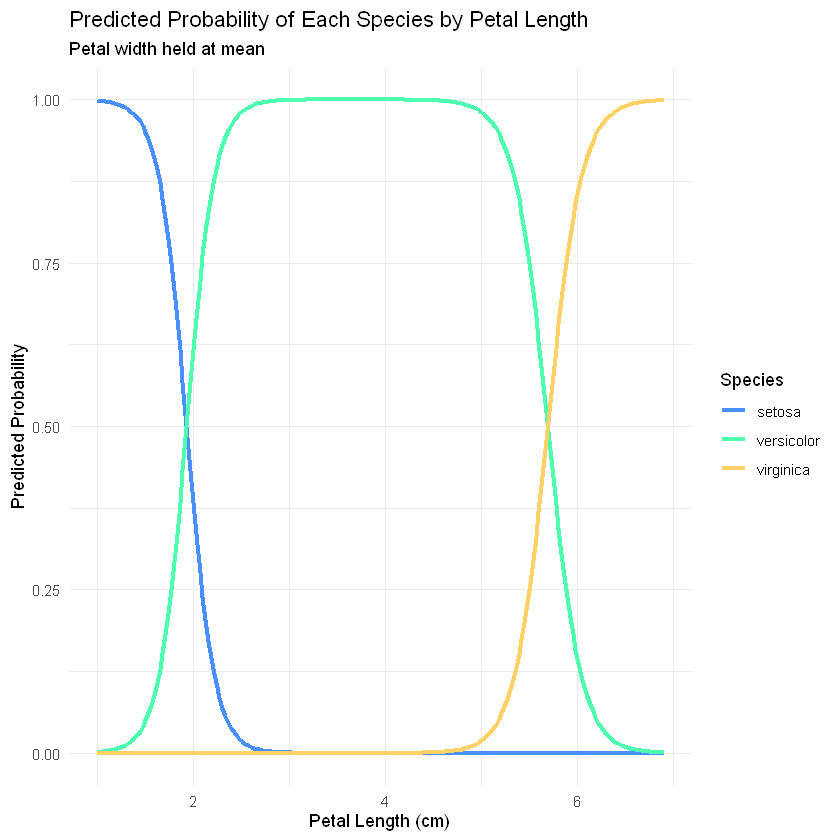

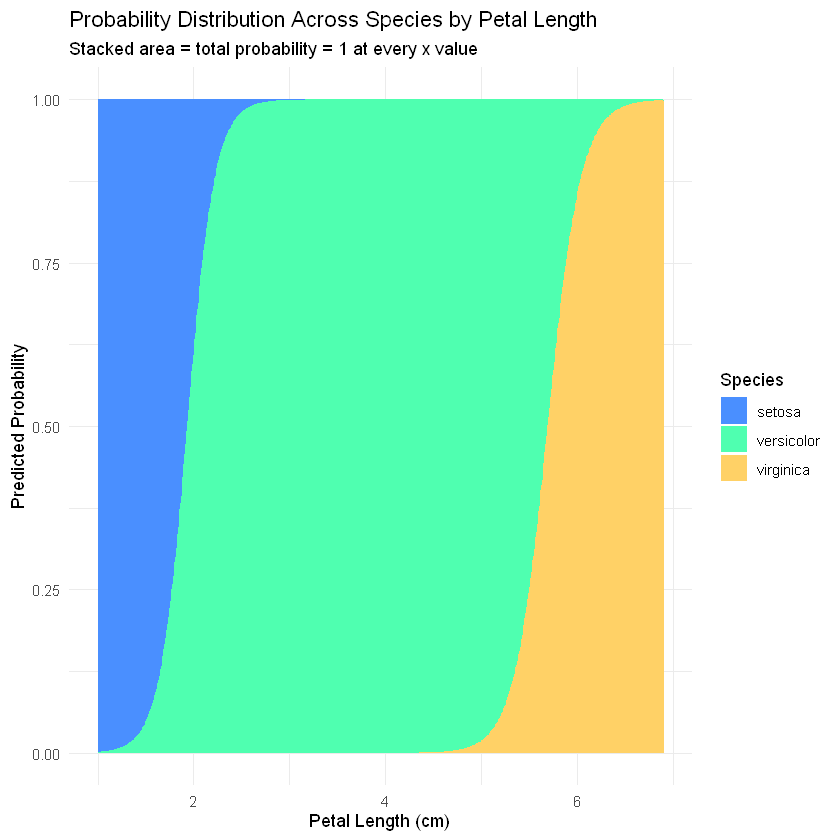

In [6]:
# ── Predicted probability curves over range of Petal.Length ──────────────────
pred_grid <- data.frame(
  Petal.Length = seq(min(iris$Petal.Length), max(iris$Petal.Length), length.out = 200),
  Petal.Width  = mean(iris$Petal.Width)  # hold at mean
)

pred_grid <- cbind(
  pred_grid,
  predict(model_multi, newdata = pred_grid, type = "probs")
) %>%
  pivot_longer(cols = c(setosa, versicolor, virginica),
               names_to  = "Species",
               values_to = "Probability")

ggplot(pred_grid, aes(x = Petal.Length, y = Probability, color = Species)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  labs(title = "Predicted Probability of Each Species by Petal Length",
       subtitle = "Petal width held at mean",
       x = "Petal Length (cm)",
       y = "Predicted Probability") +
  theme_minimal()

# ── Stacked area plot: shows how probability mass shifts ─────────────────────
ggplot(pred_grid, aes(x = Petal.Length, y = Probability, fill = Species)) +
  geom_area() +
  scale_fill_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  labs(title = "Probability Distribution Across Species by Petal Length",
       subtitle = "Stacked area = total probability = 1 at every x value",
       x = "Petal Length (cm)",
       y = "Predicted Probability") +
  theme_minimal()

---

## Reporting Results

In [10]:
# ── Clean results table ───────────────────────────────────────────────────────
coefs  <- coef(model_multi)
cis    <- confint(model_multi)

# Debugging: Check structure of cis and coefs
cat("\nStructure of cis:\n")
print(str(cis))
cat("\nRow names of coefs:\n")
print(rownames(coefs))

# Ensure cis has the expected dimensions
if (is.null(dim(cis)) || dim(cis)[3] != nrow(coefs)) {
  warning("Mismatch between cis dimensions and coefs rows. Some categories may be missing confidence intervals.")
}

rrrs   <- exp(coefs)
ci_low <- exp(cis[, "2.5 %", ])  # Extract lower bounds for each category
ci_hi  <- exp(cis[, "97.5 %", ]) # Extract upper bounds for each category

for (cat in rownames(coefs)) {
  if (!cat %in% dimnames(cis)[[3]]) {
    warning(sprintf("Category '%s' not found in cis. Skipping.", cat))
    next
  }
  cat(sprintf("\n--- %s vs. setosa ---\n", cat))
  result_df <- data.frame(
    Term    = colnames(coefs),
    RRR     = round(rrrs[cat, ], 3),
    CI_low  = round(ci_low[, cat], 3),
    CI_high = round(ci_hi[, cat], 3),
    p_value = round(p_values[cat, ], 4)
  )
  print(result_df)
}

# Standard reporting format:
# "Petal length significantly predicted species membership.
#  Compared to setosa, each 1 cm increase in petal length increased the
#  relative risk of versicolor (RRR = X.XX, 95% CI [X.XX, X.XX], p < .001)
#  and virginica (RRR = X.XX, 95% CI [X.XX, X.XX], p < .001).
#  The model achieved X% accuracy and McFadden R² = 0.XX."


Structure of cis:
 num [1:3, 1:2, 1:2] -109.8 -66.7 -150.9 64.2 80.6 ...
 - attr(*, "dimnames")=List of 3
  ..$ : chr [1:3] "(Intercept)" "Petal.Length" "Petal.Width"
  ..$ : chr [1:2] "2.5 %" "97.5 %"
  ..$ : chr [1:2] "versicolor" "virginica"
NULL

Row names of coefs:
[1] "versicolor" "virginica" 

--- versicolor vs. setosa ---
                     Term      RRR CI_low      CI_high p_value
(Intercept)   (Intercept)    0.000      0 7.580011e+27  0.6075
Petal.Length Petal.Length 1013.556      0 1.000206e+35  0.8539
Petal.Width   Petal.Width 2639.898      0 2.379412e+72  0.9225

--- virginica vs. setosa ---
                     Term        RRR CI_low      CI_high p_value
(Intercept)   (Intercept)        0.0      0 1.082542e+10  0.1438
Petal.Length Petal.Length   310895.4      0 3.518265e+37  0.7370
Petal.Width   Petal.Width 85242969.7      0 9.092801e+76  0.8218


---

## Common Pitfalls

**1. Using multinomial regression for ordered outcomes**  
If categories have a natural order (e.g. low/medium/high severity, mild/moderate/severe), use ordinal logistic regression — it is more parsimonious and respects the ordering structure.

**2. Forgetting that coefficients are relative to the reference category**  
A significant coefficient for versicolor vs. setosa says nothing about versicolor vs. virginica. To compare non-reference categories directly, refit the model with a different reference level.

**3. Not computing p-values manually**  
`nnet::multinom()` does not return p-values by default — you must compute them from z-scores as shown above. Reporting summary output without p-values is incomplete.

**4. Reporting coefficients instead of relative risk ratios**  
Exponentiate coefficients to get RRRs before reporting. Raw log-odds coefficients are difficult to interpret substantively.

**5. Ignoring the IIA assumption**  
Multinomial logistic regression assumes that the odds ratio between any two categories is unaffected by the other categories. This is not always realistic. If IIA is violated, consider nested logit or mixed logit models.

**6. Small per-category sample sizes**  
With rare categories, coefficient estimates are unstable and CIs are wide. Ensure adequate events per variable (≥ 10) for each pairwise comparison.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*